# Human Mobility in Italy

First we use Lab_Session_5.R file to gain some data insights

In [58]:
library(igraph)
library(ggplot2)
library(RColorBrewer)
library(rgl)
library(geosphere)
library(viridis)
library(patchwork)

source('common.R')

In [59]:
# Import the data
dat_nodes <- read.csv("ITA_nodes.csv", header=T, sep=",")
dat_edges <- read.csv("ITA_edges.csv", header=T, sep=",")

dat_nodes$lat <- as.numeric(dat_nodes$lat)
dat_nodes$lon <- as.numeric(dat_nodes$lon)
dat_nodes <- dat_nodes[order(dat_nodes$adm_id),]
rownames(dat_nodes) <- dat_nodes$adm_id

# Get an idea of the orders of magnitude
print(sum(dat_edges$estimated_flow)*1e-6)

# Filter out self-loops and links with zero flow
dat_edges <- dat_edges[which(dat_edges$from!=dat_edges$to & dat_edges$estimated_flow>0),]
print(sum(dat_edges$estimated_flow)*1e-6)

[1] 57.57352
[1] 4.427521


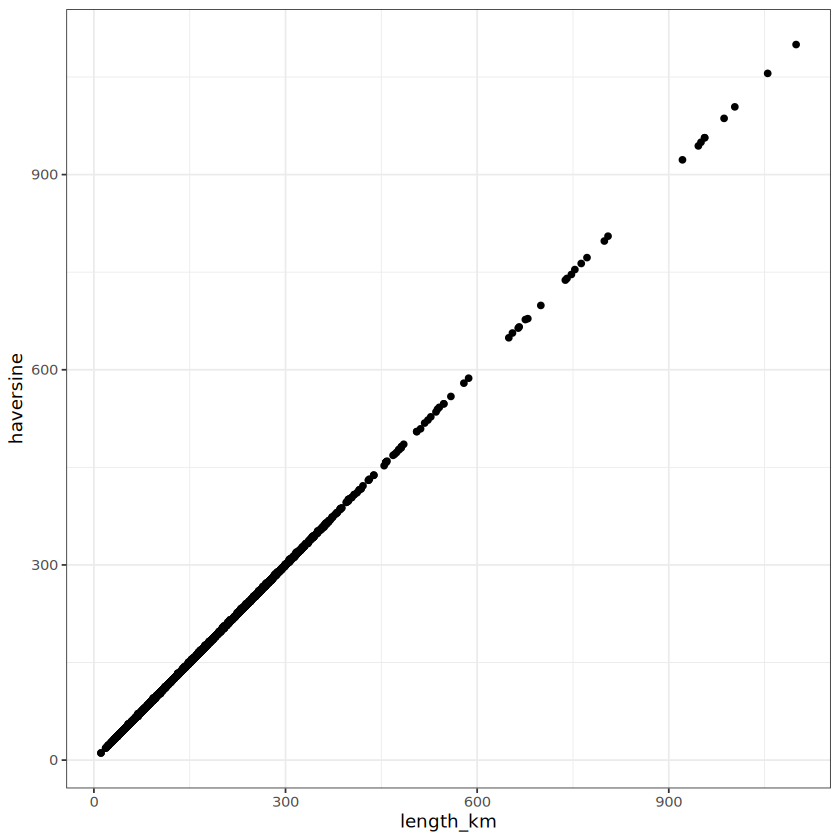

In [60]:
# we do not trust the length_km field: let us calculate the distances by ourselves
dat_edges$haversine <- 1e-3*geosphere::distHaversine( cbind(dat_nodes[dat_edges$from,]$lon,dat_nodes[dat_edges$from,]$lat), cbind(dat_nodes[dat_edges$to,]$lon,dat_nodes[dat_edges$to,]$lat) )

# if length_km was correct, then the two measures should correlate very well, and they do
ggplot(dat_edges, aes(length_km, haversine)) + theme_bw() + geom_point()

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


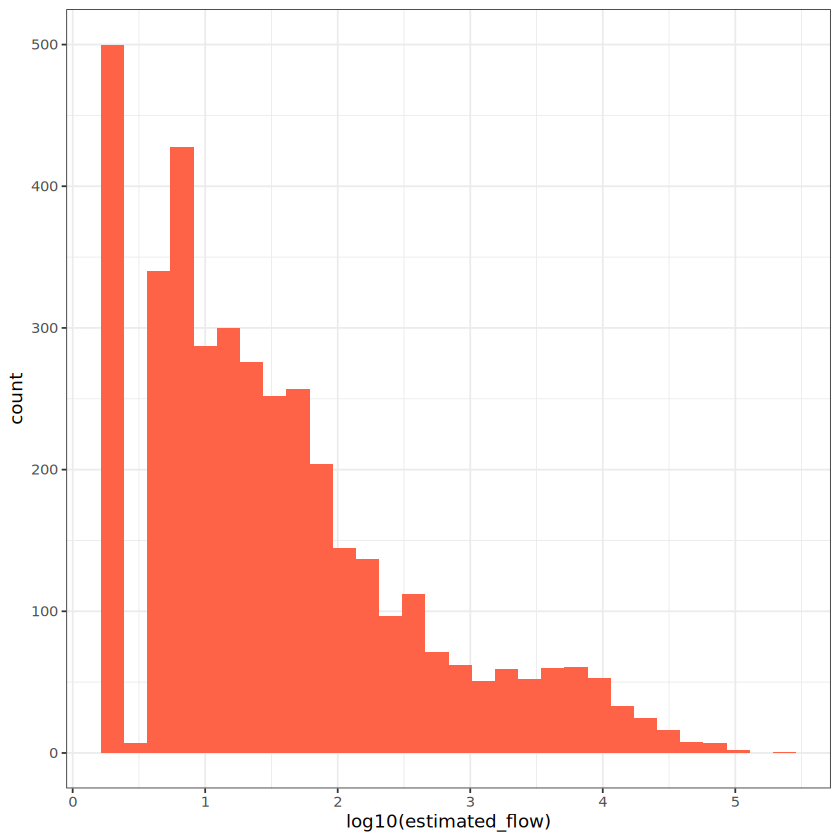

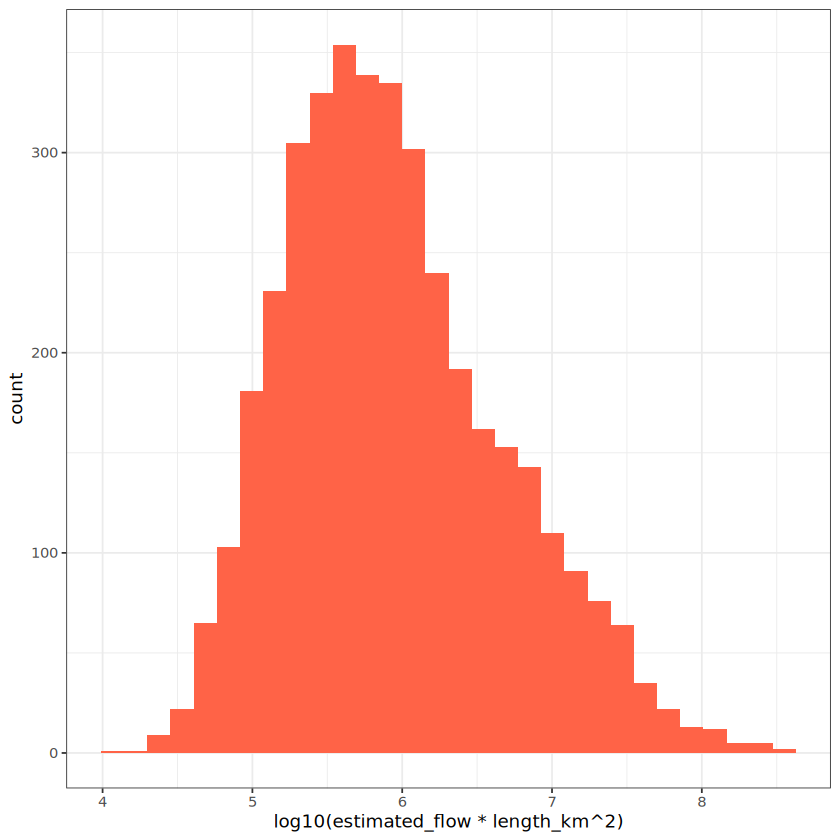

In [61]:
ggplot(dat_edges, aes(log10(estimated_flow))) + theme_bw() + geom_histogram(fill="tomato")
ggplot(dat_edges, aes(log10(estimated_flow*length_km^2))) + theme_bw() + geom_histogram(fill="tomato")

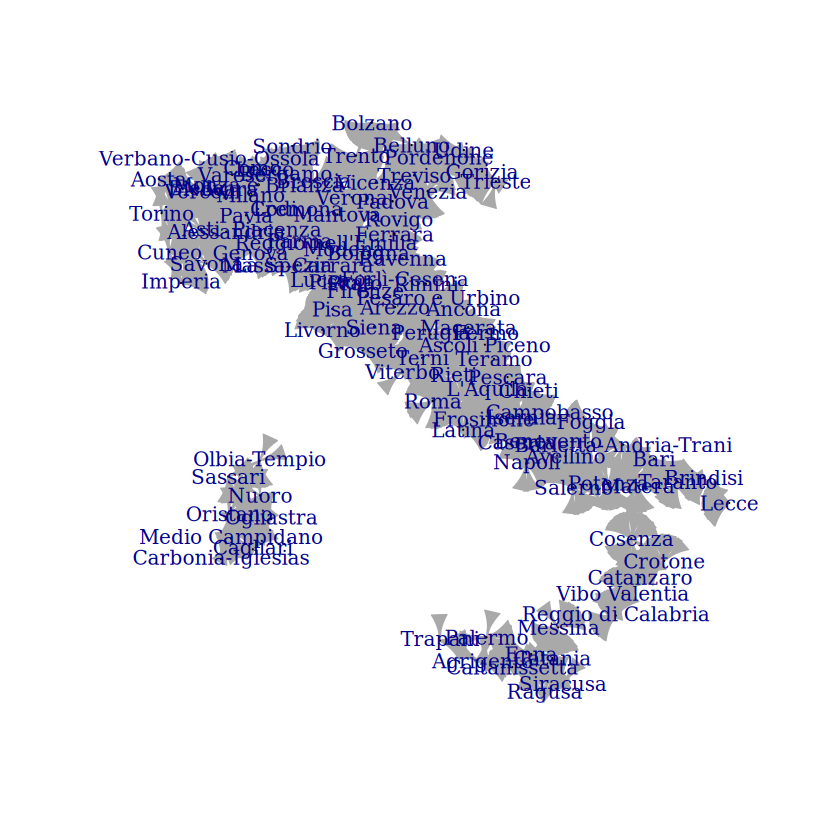

In [62]:
# Build the moblity network
g <- graph_from_data_frame(dat_edges[,c("from", "to")], directed=T, vertices=sort(dat_nodes$adm_id))
E(g)$weight <- dat_edges$estimated_flow
V(g)$pop <- dat_nodes$population
V(g)$label <- dat_nodes$adm_name


# Set the layout for plotting the network
layout <- matrix(NA, nrow(dat_nodes), 2)
layout[,1] <- dat_nodes$lon
layout[,2] <- dat_nodes$lat


# Visualize
sizes_nodes <- sqrt(strength(g, mode="all"))
sizes_edges <- E(g)$weight

plot(g, layout=layout, vertex.size=sizes_nodes/max(sizes_nodes), edge.width=sizes_edges/max(sizes_edges))

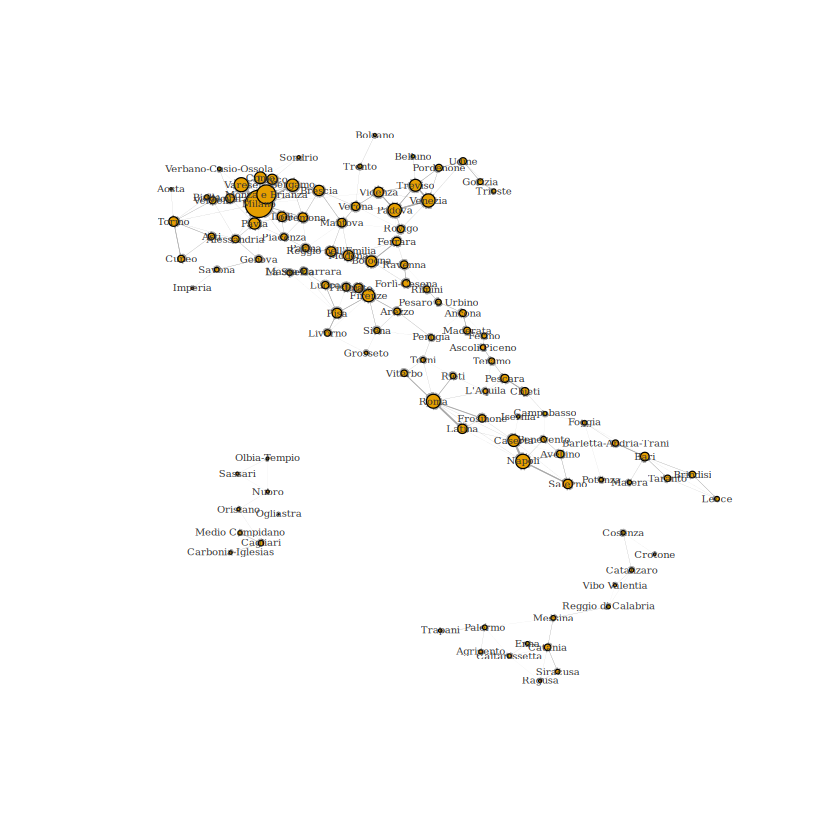

In [63]:
plot(g, layout=layout, vertex.label=V(g)$label, vertex.label.cex=.5, vertex.label.color="gray20", vertex.size=10*sizes_nodes/max(sizes_nodes), edge.arrow.size=0.05, edge.arrow.width=0.05, edge.width=5*sizes_edges/max(sizes_edges))

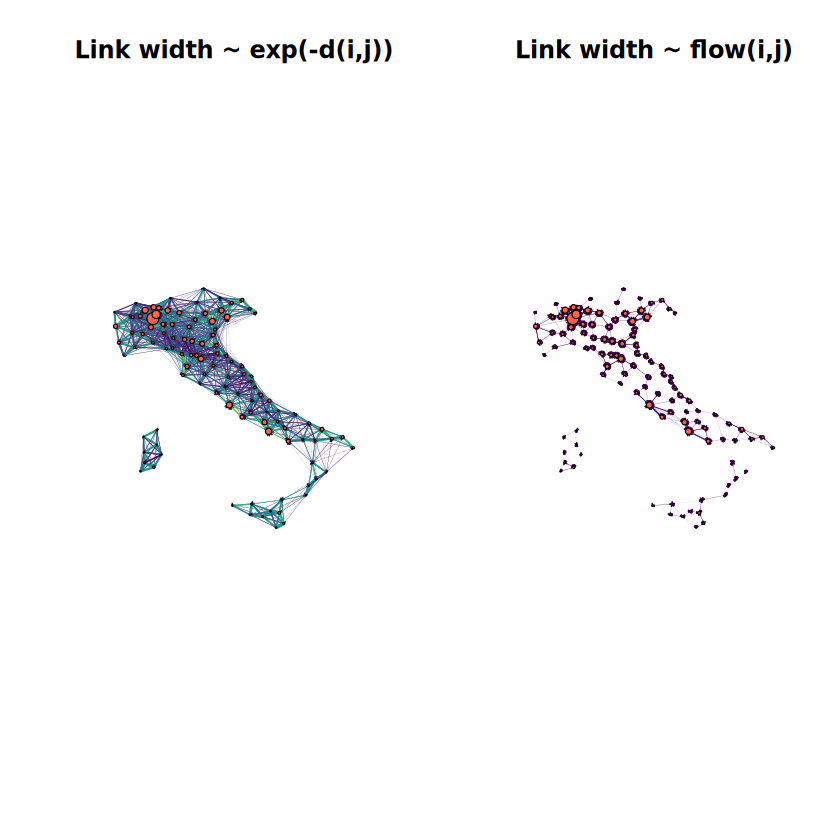

In [64]:
# let's use our distance for the visualization
mypal <- viridis::viridis_pal()(10)

par(mfrow=c(1,2))

w <- log10(E(g)$weight)
edge_colors <- vec2pal(w, mypal)
sizes_edges <- exp(-dat_edges$haversine/40)

plot(g, layout=layout, 
        vertex.label=NA, 
        vertex.label.cex=.5, 
        vertex.label.color="gray20", 
        vertex.color="tomato",
        vertex.size=10*sizes_nodes/max(sizes_nodes), 
        edge.arrow.size=0.05, 
        edge.arrow.width=0.05, 
        edge.width=5*sizes_edges/max(sizes_edges), 
        edge.color=edge_colors,
        main="Link width ~ exp(-d(i,j))")


w <- E(g)$weight
edge_colors <- vec2pal(w, mypal)
sizes_edges <- w

plot(g, layout=layout, 
        vertex.label=NA, 
        vertex.label.cex=.5, 
        vertex.label.color="gray20", 
        vertex.color="tomato",
        vertex.size=10*sizes_nodes/max(sizes_nodes), 
        edge.arrow.size=0.05, 
        edge.arrow.width=0.05, 
        edge.width=5*sizes_edges/max(sizes_edges), 
        edge.color=edge_colors,
        main="Link width ~ flow(i,j)")


## 1. Gravity Models
### Use population data to build exponential and power-law gravity models. Fit the parameters.

In [65]:
data <- data.frame(
  Ni = dat_nodes$population[match(dat_edges$from, dat_nodes$adm_id)],
  Nj = dat_nodes$population[match(dat_edges$to, dat_nodes$adm_id)],
  d  = dat_edges$haversine,
  true_flow = dat_edges$estimated_flow,
  pred_flow = NA
)

print(head(data))

# exponential gravity model
expgravity_func <- function(Ni, Nj, d, k, alpha, beta, d0) {
    return( k * Ni**alpha * Nj**beta / ( exp(d/d0) ) )
}

      Ni      Nj         d true_flow pred_flow
1 170911 2259523  73.64941   9238.94        NA
2 369018 2259523  98.85027   1491.56        NA
3 587098 2259523  75.27707  26007.20        NA
4 214638 2259523  65.88652  18231.92        NA
5 421284 2259523 102.58301   3974.58        NA
6 125666 2259523  65.30002   2071.72        NA



Formula: true_flow ~ expgravity_func(Ni, Nj, d, k, alpha, beta, d0)

Parameters:
       Estimate Std. Error t value Pr(>|t|)    
k     4.095e-06  1.064e-06   3.849 0.000121 ***
alpha 5.728e-01  1.151e-02  49.747  < 2e-16 ***
beta  1.186e+00  1.048e-02 113.180  < 2e-16 ***
d0    2.531e+01  2.707e-01  93.511  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2492 on 3899 degrees of freedom

Number of iterations to convergence: 25 
Achieved convergence tolerance: 5.888e-06


`geom_smooth()` using formula = 'y ~ x'


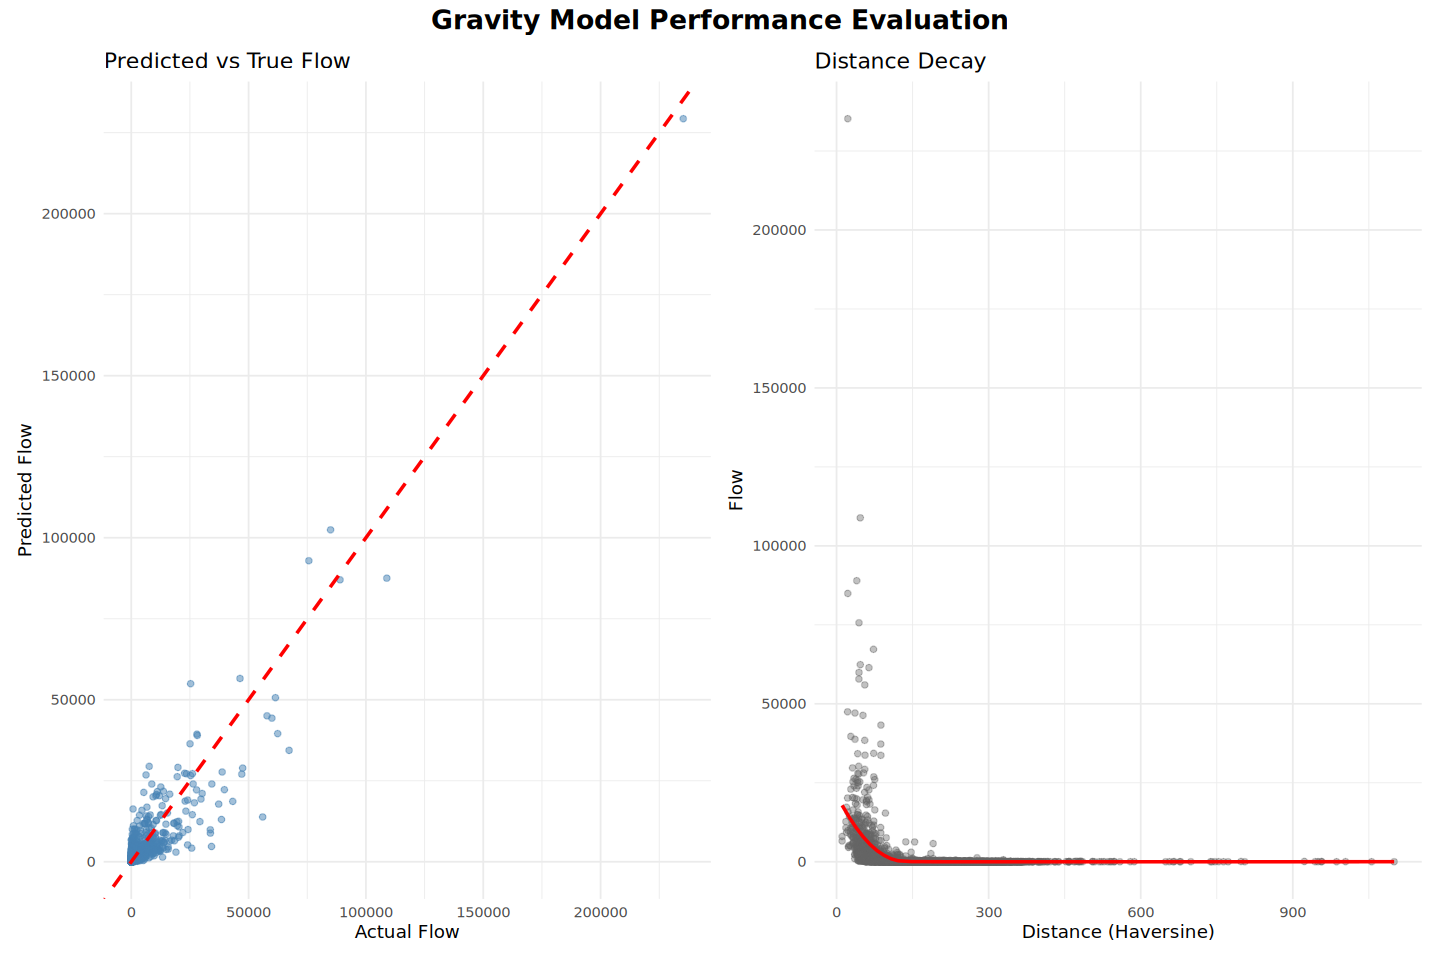

In [75]:
fit <- nls(true_flow ~ expgravity_func(Ni, Nj, d, k, alpha, beta, d0),
                     data = data,
                     start = list(k=1, alpha=1, beta=1, d0=mean(data$d)))

summary(fit)

data$pred_flow <- predict(fit)

# plot
p1 <- ggplot(data, aes(x = true_flow, y = pred_flow)) +
  geom_point(alpha = 0.5, color = "steelblue") +
  geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Predicted vs True Flow",
    x = "Actual Flow",
    y = "Predicted Flow"
  ) +
  theme_minimal()

p2 <- ggplot(data, aes(x = d)) +
  geom_point(aes(y = true_flow), alpha = 0.4, color = "gray40") +
  geom_smooth(aes(y = pred_flow), method = "loess", color = "red", se = FALSE) +
  labs(
    title = "Distance Decay",
    x = "Distance (Haversine)",
    y = "Flow"
  ) +
  theme_minimal()

options(repr.plot.width = 12, repr.plot.height = 8)

combined_figure <- p1 | p2

combined_figure + plot_annotation(
  title = "Gravity Model Performance Evaluation",
  theme = theme(plot.title = element_text(size = 16, face = "bold", hjust = 0.5))
)